# Demo - Performance Comparison (CIFAR10)

## 1. Load CIAFR10

In [1]:
# robustbench upload zip need unzip only need run once

In [2]:
import zipfile
import os

# Define the path of the ZIP file
zip_file_path = '/robustbench.zip'

# Get the directory where the ZIP file is located
extract_path = os.path.dirname(zip_file_path)

try:
    # Open the ZIP file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # Extract the ZIP file to the original directory
        zip_ref.extractall(extract_path)
    print("Unzipped successfully!")
except FileNotFoundError:
    print(f"Error: File {zip_file_path} not found.")
except zipfile.BadZipFile:
    print(f"Error: {zip_file_path} is not a valid ZIP file.")
except Exception as e:
    print(f"An unknown error occurred: {e}")


Error: File /robustbench.zip not found.


In [3]:
from robustbench.data import load_cifar10
from robustbench.utils import clean_accuracy
from utils import l2_distance
from robustbench.model_zoo.enums import BenchmarkDataset, ThreatModel
from typing import Dict, Optional, Union
from pathlib import Path
import torch
from torch import nn
images, labels = load_cifar10(n_examples=10)
device = "cuda"

Files already downloaded and verified


## 2. Standard Accuracy

In [4]:
import torch

# 只在第一次运行时 patch
if not hasattr(torch, '_original_load'):
    torch._original_load = torch.load  # 保存原始函数

def patched_torch_load(*args, **kwargs):
    if 'weights_only' not in kwargs:
        kwargs['weights_only'] = False
    return torch._original_load(*args, **kwargs)  # 调用原始函数

torch.load = patched_torch_load

In [5]:
import argparse
import dataclasses
import json
import math
import os
import warnings
from collections import OrderedDict
from pathlib import Path
from typing import Dict, Optional, Union

import torch
from torch import nn

from robustbench.model_zoo import model_dicts as all_models
from robustbench.model_zoo.enums import BenchmarkDataset, ThreatModel


ACC_FIELDS = {
    ThreatModel.corruptions: "corruptions_acc",
    ThreatModel.L2: ("external", "autoattack_acc"),
    ThreatModel.Linf: ("external", "autoattack_acc")
}


def load_model(model_name: str,
               model_dir: Union[str, Path] = './models',
               dataset: Union[str, BenchmarkDataset] = BenchmarkDataset.cifar_10,
               threat_model: Union[str, ThreatModel] = ThreatModel.Linf,
               norm: Optional[str] = None) -> nn.Module:
    """Loads a model from the model_zoo.

     The model is trained on the given ``dataset``, for the given ``threat_model``.

    :param model_name: The name used in the model zoo.
    :param model_dir: The base directory where the models are saved.
    :param dataset: The dataset on which the model is trained.
    :param threat_model: The threat model for which the model is trained.
    :param norm: Deprecated argument that can be used in place of ``threat_model``. If specified, it
      overrides ``threat_model``

    :return: A ready-to-used trained model.
    """
    dataset_: BenchmarkDataset = BenchmarkDataset(dataset)
    if norm is None:
        threat_model_: ThreatModel = ThreatModel(threat_model)
    else:
        threat_model_ = ThreatModel(norm)
        warnings.warn(
            "`norm` has been deprecated and will be removed in a future version.",
            DeprecationWarning)

    model_dir_ = Path(model_dir) / dataset_.value / threat_model_.value
    model_path = model_dir_ / f'{model_name}.pt'

    models = all_models[dataset_][threat_model_]

    model = models[model_name]['model']()

    def rm_substr_from_state_dict(state_dict, substr):
        new_state_dict = OrderedDict()
        for key in state_dict.keys():
            if substr in key:  # to delete prefix 'module.' if it exists
                new_key = key[len(substr):]
                new_state_dict[new_key] = state_dict[key]
            else:
                new_state_dict[key] = state_dict[key]
        return new_state_dict

    def add_substr_to_state_dict(state_dict, substr):
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            new_state_dict[substr + k] = v
        return new_state_dict

    def _safe_load_state_dict(model: nn.Module, model_name: str,
                              state_dict: Dict[str, torch.Tensor],
                              dataset_: BenchmarkDataset) -> nn.Module:
        known_failing_models = {
            "Andriushchenko2020Understanding", "Augustin2020Adversarial",
            "Engstrom2019Robustness", "Pang2020Boosting", "Rice2020Overfitting",
            "Rony2019Decoupling", "Wong2020Fast", "Hendrycks2020AugMix_WRN",
            "Hendrycks2020AugMix_ResNeXt", "Kireev2021Effectiveness_Gauss50percent",
            "Kireev2021Effectiveness_AugMixNoJSD", "Kireev2021Effectiveness_RLAT",
            "Kireev2021Effectiveness_RLATAugMixNoJSD", "Kireev2021Effectiveness_RLATAugMixNoJSD",
            "Kireev2021Effectiveness_RLATAugMix", "Chen2020Efficient",
            "Wu2020Adversarial", "Augustin2020Adversarial_34_10",
            "Augustin2020Adversarial_34_10_extra", "Diffenderfer2021Winning_LRR",
            "Diffenderfer2021Winning_LRR_CARD_Deck", "Diffenderfer2021Winning_Binary",
            "Diffenderfer2021Winning_Binary_CARD_Deck"
        }

        failure_messages = ['Missing key(s) in state_dict: "mu", "sigma".',
                            'Unexpected key(s) in state_dict: "model_preact_hl1.1.weight"',
                            'Missing key(s) in state_dict: "normalize.mean", "normalize.std"',
                            'Unexpected key(s) in state_dict: "conv1.scores"']

        try:
            model.load_state_dict(state_dict, strict=True)
        except RuntimeError as e:
            if (model_name in known_failing_models or dataset_ == BenchmarkDataset.imagenet
                    ) and any([msg in str(e) for msg in failure_messages]):
                model.load_state_dict(state_dict, strict=False)
            else:
                raise e

        return model

    # 直接加载本地模型文件，移除下载逻辑
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))

    if 'Kireev2021Effectiveness' in model_name or model_name == 'Andriushchenko2020Understanding':
        checkpoint = checkpoint['last']  # we take the last model (choices: 'last', 'best')
    try:
        state_dict = rm_substr_from_state_dict(checkpoint['state_dict'], 'module.')
        state_dict = rm_substr_from_state_dict(state_dict, 'model.')
    except:
        state_dict = rm_substr_from_state_dict(checkpoint, 'module.')
        state_dict = rm_substr_from_state_dict(state_dict, 'model.')

    if dataset_ == BenchmarkDataset.imagenet:
        state_dict = add_substr_to_state_dict(state_dict, 'model.')

    model = _safe_load_state_dict(model, model_name, state_dict, dataset_)

    return model.eval()


In [6]:
def clean_accuracy(model, images, labels, device):
    model.eval()
    images = images.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == labels).sum().float()  # 保留张量类型
        total = labels.size(0)
        accuracy = correct / total
    return accuracy.cpu()  # 返回 CPU 张量

In [10]:
import torch

model_path = './models/cifar10/Linf/Rice2020Overfitting.pt'  # 验证是否上传成功
try:
    checkpoint = torch.load(model_path, map_location=torch.device('cuda'))
    print("文件加载成功。")
except Exception as e:
    print(f"加载文件时出错: {e}")

文件加载成功。


In [11]:
model_list = ['Standard', 'Wong2020Fast', 'Rice2020Overfitting']
# model_list = ['Standard', 'Wong2020Fast']
# model_list = ['Rice2020Overfitting']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images = images.to(device)
labels = labels.to(device)

for model_name in model_list:
    model = load_model(model_name, norm='Linf').to(device)
    acc = clean_accuracy(model, images.to(device), labels.to(device),device)
    print('Model: {}'.format(model_name))
    print('- Standard Acc: {}'.format(acc))
    random_adv = images + torch.randn_like(images) * 0.1
    random_acc = clean_accuracy(model, random_adv, labels, device)
    print(f"Random Perturbation Accuracy: {random_acc:.4f}")

C:\Users\kwokt\AppData\Local\Temp\ipykernel_12680\1847117933.py:48: DeprecationWarning: `norm` has been deprecated and will be removed in a future version.
  warnings.warn(


Model: Standard
- Standard Acc: 1.0
Random Perturbation Accuracy: 0.3000
Model: Wong2020Fast
- Standard Acc: 1.0
Random Perturbation Accuracy: 1.0000
Model: Rice2020Overfitting
- Standard Acc: 0.800000011920929
Random Perturbation Accuracy: 0.8000


## 3. Comparison with Foolbox and ART

In [ ]:
# !pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [12]:
import datetime
import numpy as np
import warnings

warnings.filterwarnings(action='ignore')

import torch
import torch.nn as nn
import torch.optim as optim


import sys
sys.path.insert(0, '..')
# https://github.com/Harry24k/adversarial-attacks-pytorch
import torchattacks
print("torchattacks %s"%(torchattacks.__version__))

torchattacks 3.5.1


In [13]:
# pip install --upgrade torchattacks

In [14]:
print("torchattacks %s"%(torchattacks.__version__))

torchattacks 3.5.1


## 3  Attack-Linf

## CW

In [ ]:
# recod

In [15]:
def attack_and_record(model, attack, images, labels, device):
    accuracies = []
    l2_distances = []

    # 克隆原始图像并启用梯度
    orig_images = images.clone().detach().to(device)
    delta = torch.zeros_like(orig_images, requires_grad=True)

    # 自定义优化器
    optimizer = torch.optim.Adam([delta], lr=attack.lr)

    for step in range(attack.steps):
        optimizer.zero_grad()

        # 生成对抗样本（保持梯度连接）
        adv_images = orig_images + delta
        adv_images = torch.clamp(adv_images, 0, 1)

        # 前向传播
        with torch.enable_grad():
            outputs = model(adv_images)

        # 计算梯度
        optimizer.step()

        # 投影到L2球面约束
        delta.data = attack._project(delta, orig_images, attack.c)

        # 计算指标
        with torch.no_grad():
            acc = clean_accuracy(model, adv_images, labels, device)
            l2 = torch.norm(delta.view(len(images), -1), p=2, dim=1).mean().item()

        accuracies.append(acc)
        l2_distances.append(l2)
        print(f"Step {step+1}: Accuracy={acc:.4f}, L2={l2:.4f}")

    return accuracies, l2_distances


In [16]:
def attack_and_record(model, attack, images, labels, device):
    # 直接使用自定义攻击类内置的记录功能
    adv_images = attack(images, labels)
    return attack.acc_history, attack.l2_history

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchattacks.attack import Attack

class CustomCW(Attack):
    def __init__(self, model, c=1e-4, kappa=0, steps=500, lr=0.01):
        super().__init__("CustomCW", model)
        self.c = c
        self.kappa = kappa  # 置信度参数
        self.steps = steps
        self.lr = lr
        self.supported_mode = ['default']

        # 初始化跟踪指标
        self.acc_history = []
        self.l2_history = []

    def forward(self, images, labels):
        images = images.clone().detach().to(self.device)
        labels = labels.clone().detach().to(self.device)

        # 初始化扰动变量
        delta = torch.zeros_like(images, requires_grad=True)
        optimizer = optim.Adam([delta], lr=self.lr)

        # 保存原始图像用于L2计算
        orig_images = images.clone()

        for _ in range(self.steps):
            optimizer.zero_grad()

            # 生成对抗样本
            adv_images = images + delta
            adv_images = torch.clamp(adv_images, 0, 1)

            # 计算模型输出
            outputs = self.model(adv_images)

            # 计算CW损失函数
            loss = self.cw_loss(outputs, labels, delta, orig_images)

            # 梯度回传
            loss.backward()
            optimizer.step()

            # 应用L2约束（投影）
            delta.data = self._l2_project(delta, orig_images, self.c)

            # 记录中间指标
            with torch.no_grad():
                acc = (self.model(adv_images).argmax(1) == labels).float().mean().item()
                l2 = torch.norm(delta.view(len(images), -1), p=2, dim=1).mean().item()
                self.acc_history.append(acc)
                self.l2_history.append(l2)
                print(f"Step {_+1}: Accuracy={acc:.4f}, L2={l2:.4f}")

        return adv_images.detach()

    def cw_loss(self, outputs, labels, delta, orig_images):
        # 计算分类损失
        one_hot_labels = torch.eye(outputs.shape[1]).to(self.device)[labels]
        real = (one_hot_labels * outputs).sum(dim=1)
        other = ((1 - one_hot_labels) * outputs - one_hot_labels * 1e4).max(1)[0]
        loss1 = torch.clamp(real - other + self.kappa, min=0)

        # 计算L2扰动惩罚项
        loss2 = torch.norm(delta.view(len(delta), -1), dim=1, p=2)

        # 综合损失
        total_loss = loss1 + self.c * loss2.mean()
        return total_loss.mean()

    def _l2_project(self, delta, orig_images, epsilon):
        # 精确的L2投影
        delta = delta.data
        delta_flat = delta.view(delta.size(0), -1)
        norm = torch.norm(delta_flat, p=2, dim=1, keepdim=True)
        mask = (norm > epsilon).float()
        delta_flat = delta_flat * epsilon / (norm + 1e-10) * mask + delta_flat * (1 - mask)
        return delta_flat.view_as(delta)

# Defense and attack plot

In [18]:
import matplotlib.pyplot as plt

def plot_attack_defense_curves(attack_accuracies, l2_distances, model_name):

    plt.close('all')  # 清除旧图像
    plt.figure(figsize=(12, 6))
    # 绘制准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(attack_accuracies, label='Attack Accuracy', color='tab:red')
    plt.title(f'{model_name} - Robust Accuracy')  # 优化标题
    plt.xlabel('Attack Steps')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)


    plt.subplot(1, 2, 1)
    plt.plot(attack_accuracies, label='Attack Accuracy', color='tab:red')
    plt.title(f'{model_name} - Robust Accuracy')
    plt.xlabel('Attack Steps')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(l2_distances, label='L2 Distance', color='tab:blue')
    plt.title(f'{model_name} - L2 Perturbation')
    plt.xlabel('Attack Steps')
    plt.ylabel('L2 Norm')
    plt.legend()
    plt.grid(True)
    plt.show()

Model: Standard
Clean Accuracy: 1.0
Step 1: Accuracy=1.0000, L2=0.5543
Step 2: Accuracy=0.3000, L2=0.8678
Step 3: Accuracy=0.0000, L2=1.0000
Step 4: Accuracy=0.0000, L2=1.0000
Step 5: Accuracy=0.0000, L2=1.0000
Step 6: Accuracy=0.0000, L2=1.0000
Step 7: Accuracy=0.0000, L2=1.0000
Step 8: Accuracy=0.0000, L2=1.0000
Step 9: Accuracy=0.0000, L2=1.0000
Step 10: Accuracy=0.0000, L2=1.0000
Step 11: Accuracy=0.0000, L2=1.0000
Step 12: Accuracy=0.0000, L2=1.0000
Step 13: Accuracy=0.0000, L2=1.0000
Step 14: Accuracy=0.0000, L2=1.0000
Step 15: Accuracy=0.0000, L2=1.0000
Step 16: Accuracy=0.0000, L2=1.0000
Step 17: Accuracy=0.0000, L2=1.0000
Step 18: Accuracy=0.0000, L2=1.0000
Step 19: Accuracy=0.0000, L2=1.0000
Step 20: Accuracy=0.0000, L2=1.0000
Step 21: Accuracy=0.0000, L2=1.0000
Step 22: Accuracy=0.0000, L2=1.0000
Step 23: Accuracy=0.0000, L2=1.0000
Step 24: Accuracy=0.0000, L2=1.0000
Step 25: Accuracy=0.0000, L2=1.0000
Step 26: Accuracy=0.0000, L2=1.0000
Step 27: Accuracy=0.0000, L2=1.0000
S

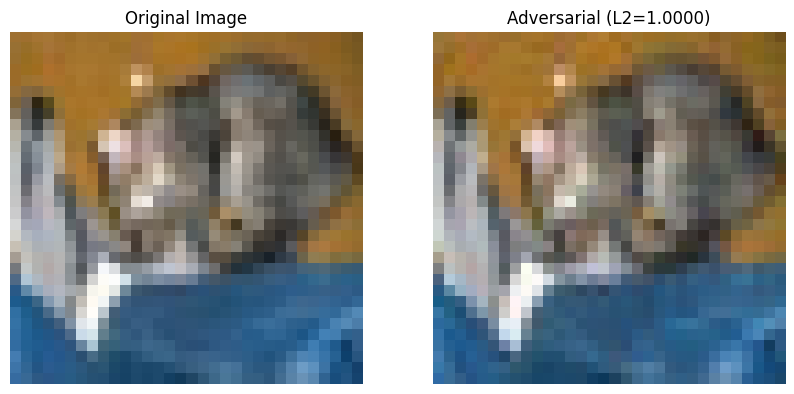

- Attack Time: 5285 ms
- Robust Acc: 0.0 / L2: 1.0 (5285 ms)


In [19]:
# 第一部分：Standard 模型攻击代码
import torch
import torchattacks
import matplotlib.pyplot as plt
from datetime import datetime

# 初始化结果存储
torchattacks_results_standard = {'acc': [], 'l2': [], 'step_acc': []}

# 处理 Standard 模型
model_name = 'Standard'
print('Model: {}'.format(model_name))
model = load_model(model_name, norm='Linf').to(device)

# 计算原始准确率
clean_acc = clean_accuracy(model, images, labels, device)
print(f"Clean Accuracy: {clean_acc}")

# 配置 CW 攻击参数
#atk = torchattacks.CW(model, c=1, kappa= 150, steps=50)

# 使用自定义攻击
atk = CustomCW(model, c=1, kappa=150, steps=50)
start = datetime.now()
# 执行攻击并记录每一步的准确率
attack_accuracies, l2_distances = attack_and_record(model, atk, images, labels, device)

adv_images = atk(images, labels)  # 获取最终对抗样本

# 反归一化（如果需要）
def denormalize(tensor):
    # 根据你的数据集调整均值和标准差
    mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).to(device)
    return tensor * std.view(1, 3, 1, 1) + mean.view(1, 3, 1, 1)

# 可视化对比原始图像和对抗样本
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0).cpu().detach().numpy())
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(adv_images[0].permute(1, 2, 0).cpu().detach().numpy())
plt.title(f"Adversarial (L2={l2_distances[-1]:.4f})")
plt.axis('off')
plt.show()
end = datetime.now()

print(f'- Attack Time: {int((end - start).total_seconds() * 1000)} ms')

acc = clean_accuracy(model, adv_images, labels, device)
l2 = l2_distance(model, images, adv_images, labels, device=device)
torchattacks_results_standard['acc'].append(acc)
torchattacks_results_standard['l2'].append(l2)
torchattacks_results_standard['step_acc'].append(attack_accuracies)

print('- Robust Acc: {} / L2: {:1.2} ({} ms)'.format(
    acc, l2, int((end - start).total_seconds() * 1000)
))


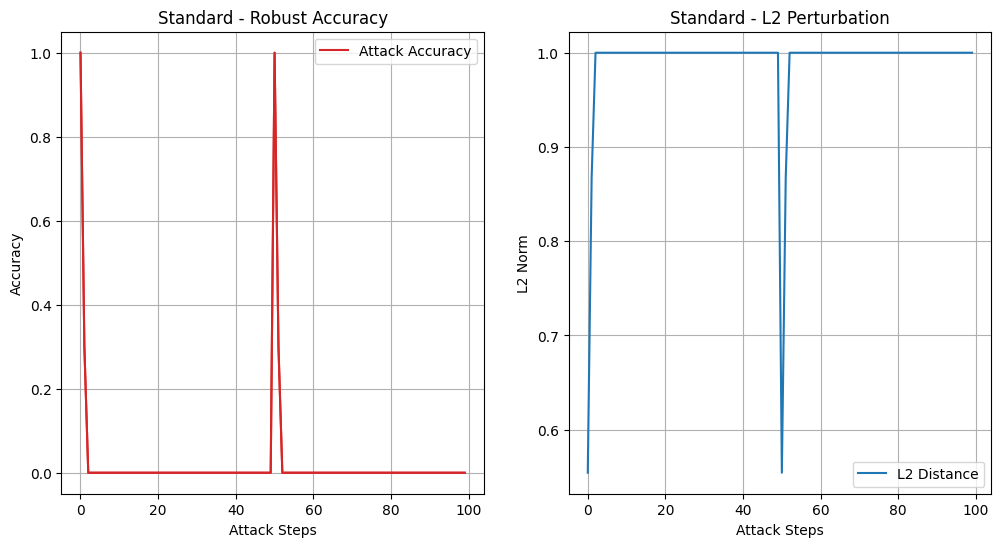

In [20]:
plot_attack_defense_curves(attack_accuracies, l2_distances, model_name)

Model: Wong2020Fast
Clean Accuracy: 1.0
Step 1: Accuracy=1.0000, L2=0.5541
Step 2: Accuracy=0.8000, L2=0.5953
Step 3: Accuracy=0.8000, L2=0.7031
Step 4: Accuracy=0.7000, L2=0.8087
Step 5: Accuracy=0.7000, L2=0.8214
Step 6: Accuracy=0.6000, L2=0.8271
Step 7: Accuracy=0.5000, L2=0.8325
Step 8: Accuracy=0.5000, L2=0.8465
Step 9: Accuracy=0.5000, L2=0.8570
Step 10: Accuracy=0.5000, L2=0.8599
Step 11: Accuracy=0.5000, L2=0.8581
Step 12: Accuracy=0.5000, L2=0.8549
Step 13: Accuracy=0.5000, L2=0.8551
Step 14: Accuracy=0.5000, L2=0.8576
Step 15: Accuracy=0.5000, L2=0.8598
Step 16: Accuracy=0.5000, L2=0.8614
Step 17: Accuracy=0.5000, L2=0.8641
Step 18: Accuracy=0.5000, L2=0.8686
Step 19: Accuracy=0.5000, L2=0.8736
Step 20: Accuracy=0.5000, L2=0.8771
Step 21: Accuracy=0.5000, L2=0.8717
Step 22: Accuracy=0.5000, L2=0.8667
Step 23: Accuracy=0.5000, L2=0.8630
Step 24: Accuracy=0.5000, L2=0.8600
Step 25: Accuracy=0.5000, L2=0.8611
Step 26: Accuracy=0.5000, L2=0.8633
Step 27: Accuracy=0.5000, L2=0.86

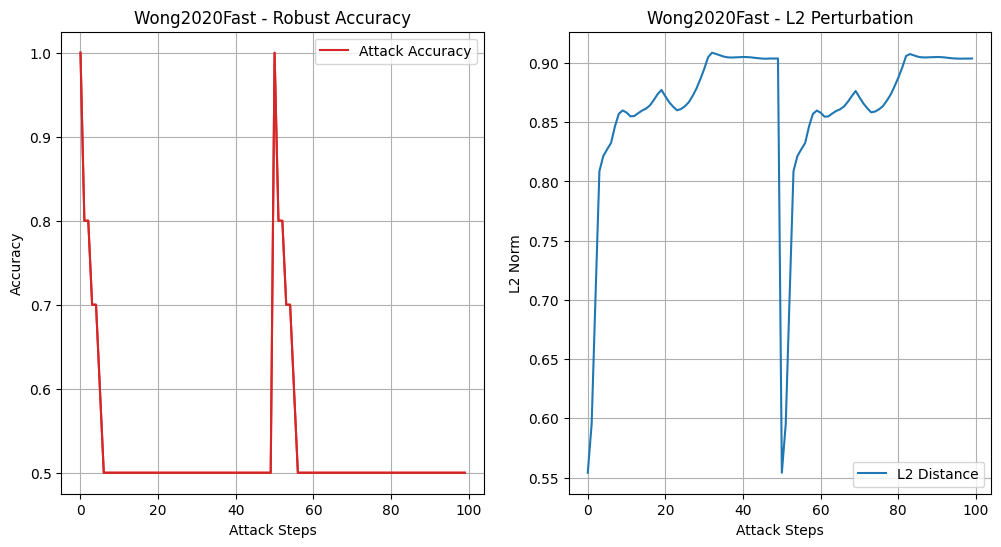

In [21]:
# CW 攻击代码
import torch
import torchattacks
import matplotlib.pyplot as plt
from datetime import datetime

# 初始化结果存储
torchattacks_results_wong = {'acc': [], 'l2': [], 'step_acc': []}

# 处理 Wong2020Fast 模型
model_name = 'Wong2020Fast'
print('Model: {}'.format(model_name))
model = load_model(model_name, norm='Linf').to(device)

# 计算原始准确率
clean_acc = clean_accuracy(model, images, labels, device)
print(f"Clean Accuracy: {clean_acc}")

# 配置 CW 攻击参数（关键优化）
atk = CustomCW(model, c=1, kappa=150, steps=50)

start = datetime.now()
# 执行攻击并记录每一步的准确率
attack_accuracies, l2_distances = attack_and_record(
    model, atk, images, labels, device
)
adv_images = atk(images, labels)  # 获取最终对抗样本
end = datetime.now()

print(f'- Attack Time: {int((end - start).total_seconds() * 1000)} ms')

acc = clean_accuracy(model, adv_images, labels, device)
l2 = l2_distance(model, images, adv_images, labels, device=device)
torchattacks_results_wong['acc'].append(acc)
torchattacks_results_wong['l2'].append(l2)
torchattacks_results_wong['step_acc'].append(attack_accuracies)

print('- Robust Acc: {} / L2: {:1.2} ({} ms)'.format(
    acc, l2, int((end - start).total_seconds() * 1000)
))

# 绘制准确率和L2曲线
plot_attack_defense_curves(attack_accuracies, l2_distances, model_name)

In [22]:
# 第3部分：Rice2020overfitting 模型攻击代码
import torch
import torchattacks
import matplotlib.pyplot as plt
from datetime import datetime


# 初始化结果存储
torchattacks_results_wong = {'acc': [], 'l2': [], 'step_acc': []}

# 处理 Rice2020overfitting 模型
model_name = 'Rice2020Overfitting'
print('Model: {}'.format(model_name))
model = load_model(model_name, norm='Linf').to(device)

# 计算原始准确率
clean_acc = clean_accuracy(model, images, labels, device)
print(f"Clean Accuracy: {clean_acc}")

# 配置 CW 攻击参数
atk = CustomCW(model, c=1, kappa=150, steps=50)

start = datetime.now()
# 执行攻击并记录每一步的准确率
attack_accuracies = attack_and_record(model, atk, images, labels, device)
adv_images = atk(images, labels)  # 获取最终对抗样本
end = datetime.now()

print(f'- Attack Time: {int((end - start).total_seconds() * 1000)} ms')

acc = clean_accuracy(model, adv_images, labels, device)
l2 = l2_distance(model, images, adv_images, labels, device=device)
torchattacks_results_wong['acc'].append(acc)
torchattacks_results_wong['l2'].append(l2)
torchattacks_results_wong['step_acc'].append(attack_accuracies)

print('- Robust Acc: {} / L2: {:1.2} ({} ms)'.format(
    acc, l2, int((end - start).total_seconds() * 1000)
))


Model: Rice2020Overfitting
Clean Accuracy: 0.800000011920929
Step 1: Accuracy=0.8000, L2=0.5541
Step 2: Accuracy=0.8000, L2=0.5613
Step 3: Accuracy=0.7000, L2=0.6597
Step 4: Accuracy=0.7000, L2=0.7581
Step 5: Accuracy=0.7000, L2=0.7693
Step 6: Accuracy=0.7000, L2=0.7693
Step 7: Accuracy=0.6000, L2=0.7863
Step 8: Accuracy=0.5000, L2=0.8136
Step 9: Accuracy=0.5000, L2=0.8239
Step 10: Accuracy=0.5000, L2=0.8254
Step 11: Accuracy=0.4000, L2=0.8203
Step 12: Accuracy=0.4000, L2=0.8179
Step 13: Accuracy=0.4000, L2=0.8179
Step 14: Accuracy=0.4000, L2=0.8160
Step 15: Accuracy=0.4000, L2=0.8140
Step 16: Accuracy=0.4000, L2=0.8145
Step 17: Accuracy=0.4000, L2=0.8154
Step 18: Accuracy=0.4000, L2=0.8145
Step 19: Accuracy=0.4000, L2=0.8127
Step 20: Accuracy=0.4000, L2=0.8121
Step 21: Accuracy=0.4000, L2=0.8113
Step 22: Accuracy=0.4000, L2=0.8095
Step 23: Accuracy=0.4000, L2=0.8083
Step 24: Accuracy=0.4000, L2=0.8076
Step 25: Accuracy=0.4000, L2=0.8060
Step 26: Accuracy=0.4000, L2=0.8046
Step 27: Acc

# Test with defense

Testing the defense method efficiency to see the accuracy of the model after applying the defense method. The accuracy should be higher than the original model without any defense method.
```python

## Proposed defense method:

1. Adversarial Training: Implementation: Augment your training data with adversarial examples

2. Input Purification/Transformation 

3. Adversarial Defense via Attention-Based Randomized Smoothing

## Defense method implementation:

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import io
import numpy as np
import copy
from tqdm import tqdm

class AdversarialDefenses:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.orig_model = copy.deepcopy(model)
        
    def defense_none(self, images):
        """Baseline: No defense"""
        return images
        
    def defense_jpeg_compression(self, images, quality=75):
        """Defense 1: JPEG Compression as input purification"""
        purified_images = []
        for img in images:
            # Convert to PIL
            img_np = img.permute(1, 2, 0).cpu().numpy()
            img_np = np.clip(img_np, 0, 1)
            img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
            
            # Apply JPEG compression
            buffer = io.BytesIO()
            img_pil.save(buffer, format="JPEG", quality=quality)
            buffer.seek(0)
            img_pil = Image.open(buffer)
            
            # Convert back to tensor
            img_np = np.array(img_pil).astype(np.float32) / 255.0
            if len(img_np.shape) == 2:  # Grayscale
                img_np = np.stack([img_np, img_np, img_np], axis=2)
            img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).to(self.device)
            purified_images.append(img_tensor)
        
        return torch.stack(purified_images)
    
    def defense_randomized_smoothing(self, images, sigma=0.1, n_samples=10):
        """Defense 2: Randomized Smoothing"""
        self.model.eval()
        with torch.no_grad():
            batch_size = images.size(0)
            
            # Initialize storage for accumulated predictions
            accumulated_preds = torch.zeros(batch_size, 10).to(self.device)  # For CIFAR-10 with 10 classes
            
            # Apply multiple noise samples and average predictions
            for _ in range(n_samples):
                # Add Gaussian noise
                noise = torch.randn_like(images) * sigma
                noisy_images = torch.clamp(images + noise, 0, 1)
                
                # Get predictions for this noise sample
                outputs = self.model(noisy_images)
                accumulated_preds += F.softmax(outputs, dim=1)
                
            # Return smoothed predictions
            return accumulated_preds / n_samples
    
    def defense_attention_smoothing(self, images, sigma=0.1, n_samples=10):
        """Defense 3: Attention-Based Randomized Smoothing"""
        self.model.eval()
        with torch.no_grad():
            batch_size = images.size(0)
            
            # First get base predictions to determine attention regions
            base_outputs = self.model(images)
            base_probs = F.softmax(base_outputs, dim=1)
            
            # Initialize storage for accumulated predictions
            accumulated_preds = torch.zeros(batch_size, 10).to(self.device)  # For CIFAR-10
            
            # Create attention masks - higher noise in less confident regions
            _, predicted = torch.max(base_probs, 1)
            confidence = torch.gather(base_probs, 1, predicted.unsqueeze(1)).squeeze()
            
            # Apply multiple noise samples with attention-based noise
            for _ in range(n_samples):
                # Generate noise with attention weighting (less noise where confident)
                attention_factors = (1.0 - confidence).unsqueeze(1).unsqueeze(2).unsqueeze(3)
                noise = torch.randn_like(images) * sigma * attention_factors
                noisy_images = torch.clamp(images + noise, 0, 1)
                
                # Get predictions for this noise sample
                outputs = self.model(noisy_images)
                accumulated_preds += F.softmax(outputs, dim=1)
                
            # Return attention-smoothed predictions
            return accumulated_preds / n_samples
    
    def adversarial_training(self, train_loader, epochs=10, defense_type='jpeg_compression'):
        """
        Implements adversarial training by fine-tuning model on adversarial examples
        """
        print(f"Starting adversarial training with {defense_type} defense...")
        
        # Set model to training mode
        self.model.train()
        
        # Optimizer
        optimizer = torch.optim.SGD(self.model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
        
        # Loss function
        criterion = nn.CrossEntropyLoss()
        
        # Create CW attack
        attack = CustomCW(self.model, c=1, kappa=0, steps=20, lr=0.01)
        
        for epoch in range(epochs):
            running_loss = 0.0
            correct = 0
            total = 0
            
            for inputs, targets in tqdm(train_loader):
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                
                # Generate adversarial examples
                adv_inputs = attack(inputs, targets)
                
                # Apply the chosen defense to adversarial examples
                if defense_type == 'jpeg_compression':
                    defended_inputs = self.defense_jpeg_compression(adv_inputs)
                elif defense_type == 'randomized_smoothing':
                    # For training, we just add random noise
                    noise = torch.randn_like(adv_inputs) * 0.1
                    defended_inputs = torch.clamp(adv_inputs + noise, 0, 1)
                elif defense_type == 'attention_smoothing':
                    # Similar approach for training
                    noise = torch.randn_like(adv_inputs) * 0.1
                    defended_inputs = torch.clamp(adv_inputs + noise, 0, 1)
                else:
                    defended_inputs = adv_inputs
                
                # Forward pass with the defended inputs
                optimizer.zero_grad()
                outputs = self.model(defended_inputs)
                loss = criterion(outputs, targets)
                
                # Backward and optimize
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item()
                
                # Calculate accuracy
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
            
            # Print epoch statistics
            accuracy = 100. * correct / total
            print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {accuracy:.2f}%')
        
        print("Adversarial training completed!")
        return self.model

## Defense Evaluation Framework

In [24]:
def evaluate_defenses(clean_images, adv_images, labels, model, defense_methods, device):
    """
    Evaluate different defense methods against adversarial examples
    """
    results = {}
    model.eval()
    
    # Initialize defense class
    defenses = AdversarialDefenses(model, device)
    
    # Evaluate each defense method
    for defense_name, defense_fn in defense_methods.items():
        print(f"Evaluating {defense_name}...")
        
        # Apply defense to adversarial examples
        if defense_name in ['Randomized Smoothing', 'Attention Smoothing']:
            # These return probabilities directly
            if defense_name == 'Randomized Smoothing':
                defended_outputs = defenses.defense_randomized_smoothing(adv_images)
            else:
                defended_outputs = defenses.defense_attention_smoothing(adv_images)
            
            # Calculate accuracy from probabilities
            _, predicted = defended_outputs.max(1)
            defended_acc = (predicted == labels).float().mean().item()
            
        else:
            # Other defenses return images that need to be passed through the model
            if defense_name == 'No Defense':
                defended_images = defenses.defense_none(adv_images)
            elif defense_name == 'JPEG Compression':
                defended_images = defenses.defense_jpeg_compression(adv_images)
            else:
                defended_images = adv_images  # Fallback
            
            # Calculate accuracy
            with torch.no_grad():
                outputs = model(defended_images)
                _, predicted = outputs.max(1)
                defended_acc = (predicted == labels).float().mean().item()
        
        # Calculate clean accuracy with defense (for checking if defense reduces clean performance)
        if defense_name in ['Randomized Smoothing', 'Attention Smoothing']:
            if defense_name == 'Randomized Smoothing':
                clean_outputs = defenses.defense_randomized_smoothing(clean_images)
            else:
                clean_outputs = defenses.defense_attention_smoothing(clean_images)
            
            _, predicted = clean_outputs.max(1)
            clean_acc = (predicted == labels).float().mean().item()
        else:
            if defense_name == 'No Defense':
                defended_clean = defenses.defense_none(clean_images)
            elif defense_name == 'JPEG Compression':
                defended_clean = defenses.defense_jpeg_compression(clean_images)
            else:
                defended_clean = clean_images
                
            with torch.no_grad():
                outputs = model(defended_clean)
                _, predicted = outputs.max(1)
                clean_acc = (predicted == labels).float().mean().item()
        
        # Store results
        results[defense_name] = {
            'clean_accuracy': clean_acc * 100,
            'adversarial_accuracy': defended_acc * 100,
            'robustness_retention': (defended_acc / clean_acc) * 100 if clean_acc > 0 else 0
        }
    
    return results

## Main Comparison Script

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from robustbench.data import load_cifar10
from robustbench.utils import clean_accuracy

# Load data and models from your existing code
images, labels = load_cifar10(n_examples=50)  # Use more examples for better evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load all models for comparison
model_list = ['Standard', 'Wong2020Fast', 'Rice2020Overfitting']
models = {}
for model_name in model_list:
    models[model_name] = load_model(model_name, norm='Linf').to(device)
    
# Set up attack
atk = CustomCW(models['Standard'], c=1, kappa=150, steps=50)

# Define defense methods to evaluate
defense_methods = {
    'No Defense': 'defense_none',
    'JPEG Compression': 'defense_jpeg_compression',
    'Randomized Smoothing': 'defense_randomized_smoothing',
    'Attention Smoothing': 'defense_attention_smoothing'
}

# Run evaluation for each model
all_results = {}

for model_name in model_list:
    print(f"\nEvaluating defenses for {model_name} model...")
    model = models[model_name]
    
    # Generate adversarial examples for this model
    adv_model = CustomCW(model, c=1, kappa=150, steps=50)
    adv_images = adv_model(images.to(device), labels.to(device))
    
    # Evaluate clean accuracy
    clean_acc = clean_accuracy(model, images.to(device), labels.to(device))
    
    # Evaluate adversarial accuracy without defense
    adv_acc = clean_accuracy(model, adv_images, labels.to(device))
    
    print(f"Model: {model_name}")
    print(f"Clean accuracy: {clean_acc:.4f}")
    print(f"Adversarial accuracy (no defense): {adv_acc:.4f}")
    
    # Evaluate all defenses
    results = evaluate_defenses(images.to(device), adv_images, labels.to(device), model, defense_methods, device)
    all_results[model_name] = results

# Create a comparison table
def create_comparison_table(all_results, metric='adversarial_accuracy'):
    """Create a table comparing all models and defenses"""
    data = []
    for model_name, results in all_results.items():
        for defense_name, metrics in results.items():
            data.append({
                'Model': model_name,
                'Defense': defense_name,
                'Clean Accuracy (%)': metrics['clean_accuracy'],
                'Adversarial Accuracy (%)': metrics['adversarial_accuracy'],
                'Robustness Retention (%)': metrics['robustness_retention']
            })
    
    return pd.DataFrame(data)

# Generate comparison table
comparison_table = create_comparison_table(all_results)
print("\nComparison of Defense Methods:")
print(comparison_table.to_string(index=False))

# Create visualizations
plt.figure(figsize=(14, 8))
sns.barplot(x='Defense', y='Adversarial Accuracy (%)', hue='Model', data=comparison_table)
plt.title('Comparison of Defense Methods Against CW Attack')
plt.xlabel('Defense Method')
plt.ylabel('Adversarial Accuracy (%)')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('defense_comparison.png')
plt.show()

# Create a heatmap for better visualization
pivot_table = comparison_table.pivot_table(
    index='Defense', 
    columns='Model', 
    values='Adversarial Accuracy (%)'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Adversarial Accuracy (%) by Model and Defense')
plt.tight_layout()
plt.savefig('defense_heatmap.png')
plt.show()

Files already downloaded and verified

Evaluating defenses for Standard model...
Step 1: Accuracy=0.9600, L2=0.5543
Step 2: Accuracy=0.3400, L2=0.8766
Step 3: Accuracy=0.1000, L2=1.0000
Step 4: Accuracy=0.0200, L2=1.0000
Step 5: Accuracy=0.0200, L2=1.0000
Step 6: Accuracy=0.0000, L2=1.0000
Step 7: Accuracy=0.0000, L2=1.0000
Step 8: Accuracy=0.0000, L2=1.0000
Step 9: Accuracy=0.0000, L2=1.0000
Step 10: Accuracy=0.0000, L2=1.0000
Step 11: Accuracy=0.0000, L2=1.0000
Step 12: Accuracy=0.0000, L2=1.0000
Step 13: Accuracy=0.0000, L2=1.0000
Step 14: Accuracy=0.0000, L2=1.0000
Step 15: Accuracy=0.0000, L2=1.0000
Step 16: Accuracy=0.0000, L2=1.0000
Step 17: Accuracy=0.0000, L2=1.0000
Step 18: Accuracy=0.0000, L2=1.0000
Step 19: Accuracy=0.0000, L2=1.0000
Step 20: Accuracy=0.0000, L2=1.0000
Step 21: Accuracy=0.0000, L2=1.0000
Step 22: Accuracy=0.0000, L2=1.0000
Step 23: Accuracy=0.0000, L2=1.0000
Step 24: Accuracy=0.0000, L2=1.0000
Step 25: Accuracy=0.0000, L2=1.0000
Step 26: Accuracy=0.0000, L2

## Implementing Adversarial Training Module

In [ ]:
# Function to load CIFAR-10 for adversarial training
def load_cifar10_for_training(batch_size=128):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ])
    
    transform_test = transforms.Compose([
        transforms.ToTensor(),
    ])
    
    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train)
    
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    
    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test)
    
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=100, shuffle=False, num_workers=2)
    
    return trainloader, testloader

# Function to evaluate a model with different defenses
def evaluate_model_with_defenses(model, adv_generator, test_loader, device, defense_methods):
    """Comprehensive evaluation of a model with different defenses"""
    defenses = AdversarialDefenses(model, device)
    
    results = {
        'clean': {},
        'adversarial': {}
    }
    
    # Evaluate on clean test set
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    clean_acc = 100. * correct / total
    results['clean']['No Defense'] = clean_acc
    
    # Generate adversarial examples and evaluate without defense
    correct = 0
    total = 0
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        adv_inputs = adv_generator(inputs, targets)
        
        with torch.no_grad():
            outputs = model(adv_inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    adv_acc_no_defense = 100. * correct / total
    results['adversarial']['No Defense'] = adv_acc_no_defense
    
    # Evaluate with each defense
    for defense_name, defense_fn in defense_methods.items():
        if defense_name == 'No Defense':
            continue
        
        # Evaluate on clean data with defense
        correct = 0
        total = 0
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            if defense_name == 'JPEG Compression':
                defended_inputs = defenses.defense_jpeg_compression(inputs)
            elif defense_name == 'Randomized Smoothing':
                with torch.no_grad():
                    probs = defenses.defense_randomized_smoothing(inputs)
                    _, predicted = probs.max(1)
                    total += targets.size(0)
                    correct += predicted.eq(targets).sum().item()
                continue
            elif defense_name == 'Attention Smoothing':
                with torch.no_grad():
                    probs = defenses.defense_attention_smoothing(inputs)
                    _, predicted = probs.max(1)
                    total += targets.size(0)
                    correct += predicted.eq(targets).sum().item()
                continue
            else:
                defended_inputs = inputs
            
            with torch.no_grad():
                outputs = model(defended_inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        clean_acc_with_defense = 100. * correct / total
        results['clean'][defense_name] = clean_acc_with_defense
        
        # Evaluate on adversarial examples with defense
        correct = 0
        total = 0
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            adv_inputs = adv_generator(inputs, targets)
            
            if defense_name == 'JPEG Compression':
                defended_inputs = defenses.defense_jpeg_compression(adv_inputs)
            elif defense_name == 'Randomized Smoothing':
                with torch.no_grad():
                    probs = defenses.defense_randomized_smoothing(adv_inputs)
                    _, predicted = probs.max(1)
                    total += targets.size(0)
                    correct += predicted.eq(targets).sum().item()
                continue
            elif defense_name == 'Attention Smoothing':
                with torch.no_grad():
                    probs = defenses.defense_attention_smoothing(adv_inputs)
                    _, predicted = probs.max(1)
                    total += targets.size(0)
                    correct += predicted.eq(targets).sum().item()
                continue
            else:
                defended_inputs = adv_inputs
            
            with torch.no_grad():
                outputs = model(defended_inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        adv_acc_with_defense = 100. * correct / total
        results['adversarial'][defense_name] = adv_acc_with_defense
    
    return results

## Full Experiment with Adversarial Training

In [ ]:
# Main experiment with adversarial training
def run_full_experiment():
    """Run full experiment with all defenses and adversarial training"""
    # Load data
    train_loader, test_loader = load_cifar10_for_training(batch_size=128)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load models
    model_list = ['Standard', 'Wong2020Fast', 'Rice2020Overfitting']
    models = {}
    for model_name in model_list:
        models[model_name] = load_model(model_name, norm='Linf').to(device)
    
    # Define defense methods
    defense_methods = {
        'No Defense': 'defense_none',
        'JPEG Compression': 'defense_jpeg_compression',
        'Randomized Smoothing': 'defense_randomized_smoothing',
        'Attention Smoothing': 'defense_attention_smoothing'
    }
    
    # Create CW attack
    cw_attack = lambda model: CustomCW(model, c=1, kappa=150, steps=50)
    
    # Results for normal models
    all_results = {}
    for model_name, model in models.items():
        print(f"\nEvaluating base model: {model_name}")
        results = evaluate_model_with_defenses(
            model, cw_attack(model), test_loader, device, defense_methods
        )
        all_results[f"{model_name} (Base)"] = results
    
    # Perform adversarial training
    adv_trained_models = {}
    for model_name, model in models.items():
        print(f"\nPerforming adversarial training on {model_name}")
        
        # Make a copy of the model for adversarial training
        adv_model = copy.deepcopy(model)
        
        # Initialize defenses
        defenses = AdversarialDefenses(adv_model, device)
        
        # Perform adversarial training
        adv_model = defenses.adversarial_training(
            train_loader, epochs=3, defense_type='jpeg_compression'
        )
        
        # Save the adversarially trained model
        adv_trained_models[model_name] = adv_model
        
        # Evaluate the adversarially trained model
        print(f"\nEvaluating adversarially trained model: {model_name}")
        results = evaluate_model_with_defenses(
            adv_model, cw_attack(adv_model), test_loader, device, defense_methods
        )
        all_results[f"{model_name} (Adv. Trained)"] = results
    
    # Create comparison tables and visualizations
    create_comprehensive_report(all_results)
    
    return all_results, adv_trained_models

def create_comprehensive_report(all_results):
    """Create a comprehensive report with tables and visualizations"""
    # Create DataFrame for clean accuracy
    clean_data = []
    for model_name, results in all_results.items():
        for defense_name, accuracy in results['clean'].items():
            clean_data.append({
                'Model': model_name,
                'Defense': defense_name,
                'Clean Accuracy (%)': accuracy
            })
    
    clean_df = pd.DataFrame(clean_data)
    
    # Create DataFrame for adversarial accuracy
    adv_data = []
    for model_name, results in all_results.items():
        for defense_name, accuracy in results['adversarial'].items():
            adv_data.append({
                'Model': model_name,
                'Defense': defense_name,
                'Adversarial Accuracy (%)': accuracy
            })
    
    adv_df = pd.DataFrame(adv_data)
    
    # Merge the DataFrames
    merged_df = pd.merge(clean_df, adv_df, on=['Model', 'Defense'])
    
    # Calculate robustness retention
    merged_df['Robustness Retention (%)'] = (
        merged_df['Adversarial Accuracy (%)'] / merged_df['Clean Accuracy (%)'] * 100
    )
    
    # Print the results
    print("\nComprehensive Results:")
    print(merged_df.to_string(index=False))
    
    # Create visualizations
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 1, 1)
    sns.barplot(x='Defense', y='Adversarial Accuracy (%)', hue='Model', data=merged_df)
    plt.title('Adversarial Accuracy by Model and Defense')
    plt.xlabel('Defense Method')
    plt.ylabel('Adversarial Accuracy (%)')
    plt.xticks(rotation=45)
    plt.legend(title='Model')
    
    plt.subplot(2, 1, 2)
    sns.barplot(x='Defense', y='Robustness Retention (%)', hue='Model', data=merged_df)
    plt.title('Robustness Retention by Model and Defense')
    plt.xlabel('Defense Method')
    plt.ylabel('Robustness Retention (%)')
    plt.xticks(rotation=45)
    plt.legend(title='Model')
    
    plt.tight_layout()
    plt.savefig('comprehensive_defense_comparison.png')
    plt.show()
    
    # Create heatmaps
    plt.figure(figsize=(12, 15))
    
    plt.subplot(2, 1, 1)
    pivot_clean = merged_df.pivot_table(
        index='Defense', 
        columns='Model', 
        values='Clean Accuracy (%)'
    )
    sns.heatmap(pivot_clean, annot=True, cmap='YlGnBu', fmt='.2f')
    plt.title('Clean Accuracy (%) by Model and Defense')
    
    plt.subplot(2, 1, 2)
    pivot_adv = merged_df.pivot_table(
        index='Defense', 
        columns='Model', 
        values='Adversarial Accuracy (%)'
    )
    sns.heatmap(pivot_adv, annot=True, cmap='YlGnBu', fmt='.2f')
    plt.title('Adversarial Accuracy (%) by Model and Defense')
    
    plt.tight_layout()
    plt.savefig('defense_accuracy_heatmaps.png')
    plt.show()
    
    # Create a retention heatmap
    plt.figure(figsize=(10, 6))
    pivot_retention = merged_df.pivot_table(
        index='Defense', 
        columns='Model', 
        values='Robustness Retention (%)'
    )
    sns.heatmap(pivot_retention, annot=True, cmap='YlGnBu', fmt='.2f')
    plt.title('Robustness Retention (%) by Model and Defense')
    plt.tight_layout()
    plt.savefig('robustness_retention_heatmap.png')
    plt.show()

# Run the experiment
all_results, adv_trained_models = run_full_experiment()